In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv(r"/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")

In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [6]:
df.shape

(17966, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [8]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [9]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

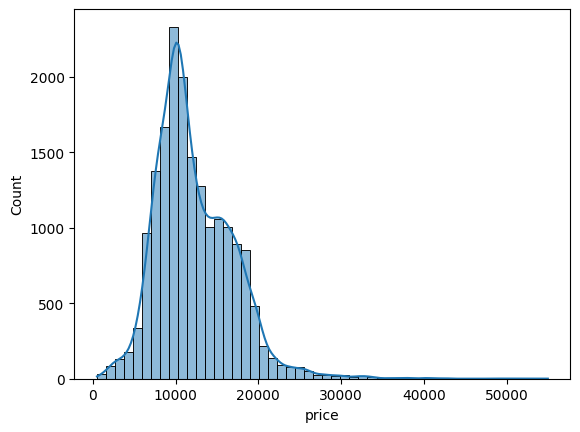

In [10]:
#EDA

sns.histplot(df['price'],bins= 50, kde=True)

<Axes: >

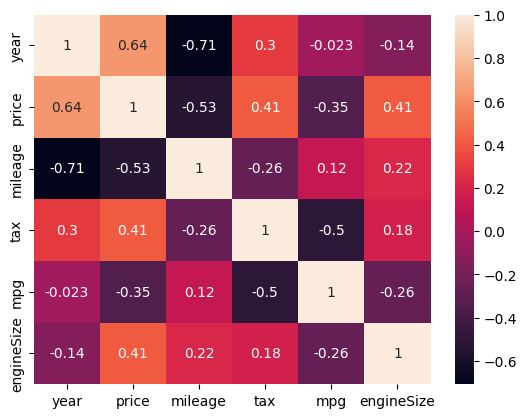

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

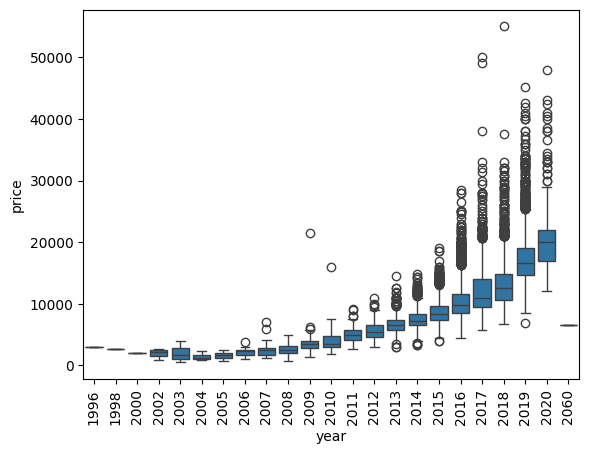

In [12]:
sns.boxplot(data = df, x= 'year', y= 'price')
plt.xticks(rotation = 90)

<Axes: xlabel='mileage', ylabel='price'>

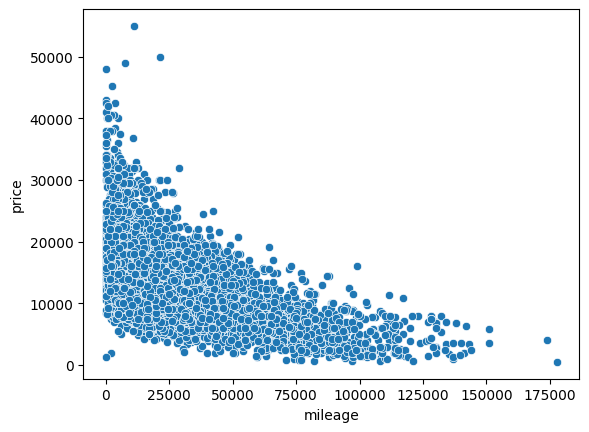

In [13]:
sns.scatterplot(data=df, x= 'mileage', y= 'price')

<Axes: xlabel='engineSize', ylabel='price'>

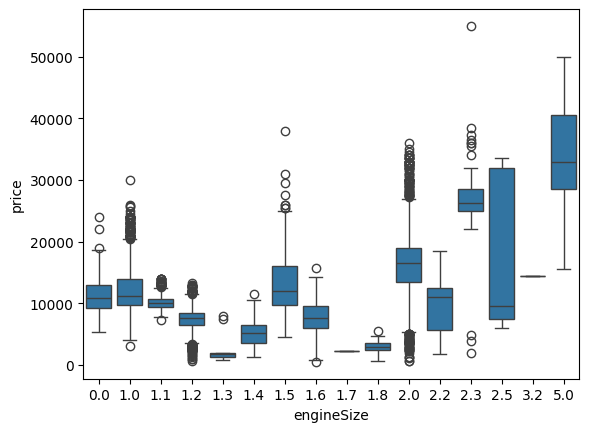

In [14]:
sns.boxplot(data= df, x= 'engineSize' , y= 'price')

<Axes: xlabel='transmission', ylabel='price'>

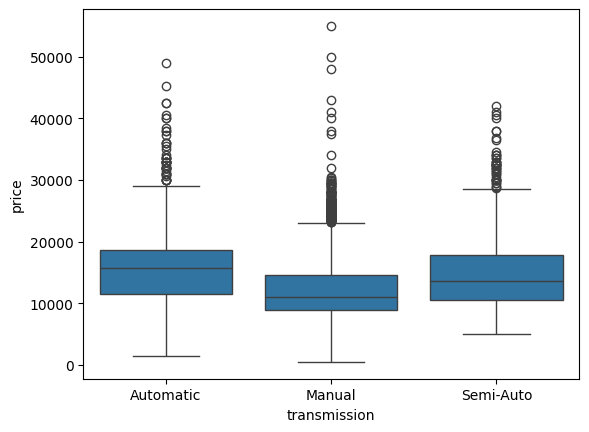

In [15]:
sns.boxplot(data = df, x = 'transmission', y= 'price')

<Axes: xlabel='fuelType', ylabel='price'>

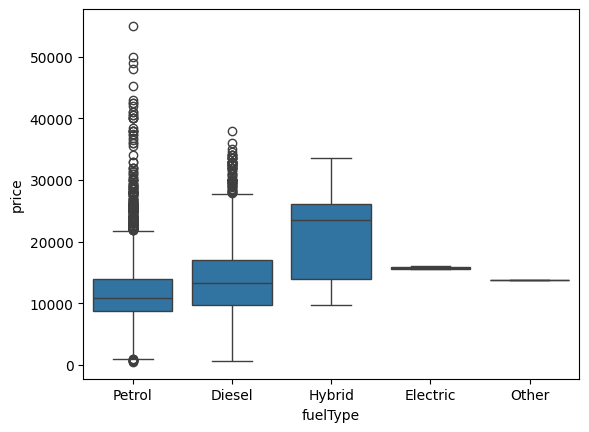

In [16]:
sns.boxplot(data=df,x = 'fuelType' , y='price')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

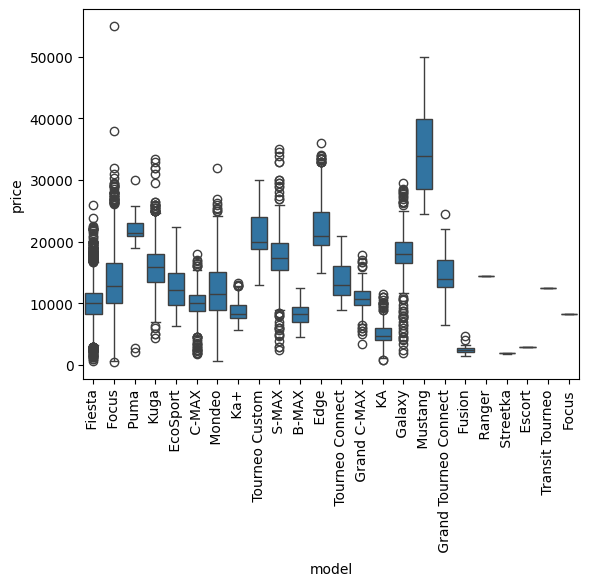

In [17]:
sns.boxplot(data=df,x= 'model', y='price')
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, '0'),
  Text(1, 0, '20'),
  Text(2, 0, '22'),
  Text(3, 0, '30'),
  Text(4, 0, '110'),
  Text(5, 0, '115'),
  Text(6, 0, '120'),
  Text(7, 0, '125'),
  Text(8, 0, '135'),
  Text(9, 0, '140'),
  Text(10, 0, '145'),
  Text(11, 0, '150'),
  Text(12, 0, '155'),
  Text(13, 0, '160'),
  Text(14, 0, '165'),
  Text(15, 0, '185'),
  Text(16, 0, '190'),
  Text(17, 0, '195'),
  Text(18, 0, '200'),
  Text(19, 0, '205'),
  Text(20, 0, '210'),
  Text(21, 0, '220'),
  Text(22, 0, '230'),
  Text(23, 0, '235'),
  Text(24, 0, '240'),
  Text(25, 0, '260'),
  Text(26, 0, '265'),
  Text(27, 0, '270'),
  Text(28, 0, '290'),
  Text(29, 0, '300'),
  Text(30, 0, '305'),
  Text(31, 0, '325'),
  Text(32, 0, '330'),
  Text(33, 0, '555'),
  Text(34, 0, '570'),
  Text(35, 0, '580')])

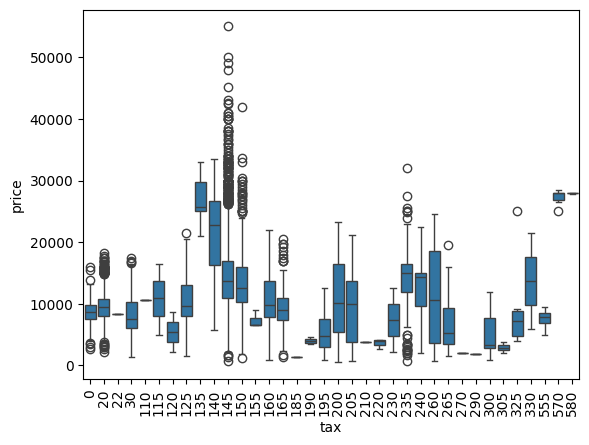

In [18]:
sns.boxplot(data=df, x = 'tax', y= 'price')
plt.xticks(rotation = 90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89],
 [Text(0, 0, '20.8'),
  Text(1, 0, '20.9'),
  Text(2, 0, '22.1'),
  Text(3, 0, '22.6'),
  Text(4, 0, '22.8'),
  Text(5, 0, '23.5'),
  Text(6, 0, '23.7'),
  Text(7, 0, '23.9'),
  Text(8, 0, '24.8'),
  Text(9, 0, '26.3'),
  Text(10, 0, '27.4'),
  Text(11, 0, '28.0'),
  Text(12, 0, '28.3'),
  Text(13, 0, '28.5'),
  Text(14, 0, '28.8'),
  Text(15, 0, '29.1'),
  Text(16, 0, '29.4'),
  Text(17, 0, '30.1'),
  Text(18, 0, '30.4'),
  Text(19, 0, '30.7'),
  Text(20, 0, '31.0

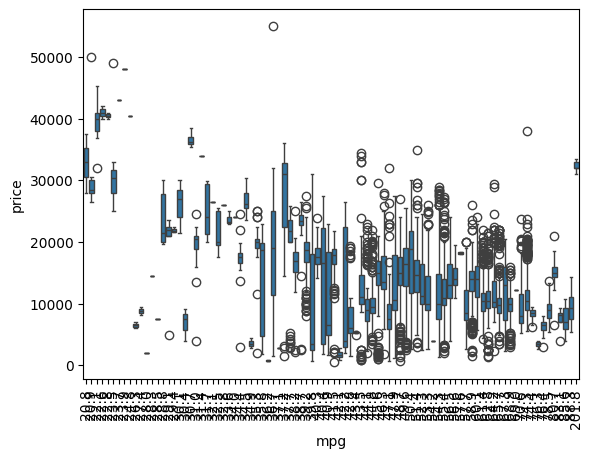

In [19]:
sns.boxplot(data= df , x = 'mpg', y= 'price')
plt.xticks(rotation = 90)

In [20]:
X = df.drop(columns = ['price'], axis= 1)
y= df['price']

In [21]:
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [22]:
#ENCODING
X_one_encode = pd.get_dummies(X, columns = ['model', 'transmission', 'fuelType'], drop_first= True)

In [23]:
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,2014,40700,30,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,2015,7010,20,67.3,1.6,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,2018,5007,145,57.7,1.2,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [24]:
X_one_encode= X_one_encode.astype(int)

In [25]:
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [26]:
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()

columns = ['model','transmission','fuelType']

Xlabel = X.copy()

for i in columns:
    Xlabel[i] = encode.fit_transform(Xlabel[i])

In [27]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


In [28]:
Xlabel['fuelType'].value_counts()

fuelType
4    12179
0     5762
2       22
1        2
3        1
Name: count, dtype: int64

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
numerical_cols = ['year','mileage','tax','mpg','engineSize']
scaler=StandardScaler()
X_one_encode[numerical_cols] = scaler.fit_transform(X_one_encode[numerical_cols])

In [31]:
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.029814,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [32]:
Xlabel.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [33]:
Xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] = scaler.fit_transform(Xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] )

In [34]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
X_train,X_test,y_train,y_test= train_test_split(X_one_encode, y, test_size= 0.20, random_state=42)

In [37]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [38]:
y_pred= model.predict(X_test)

In [39]:
y_pred

array([ 6866.3580764 ,  9347.6810129 ,  9362.18320785, ...,
       31454.95287518,  9781.20362786, 15253.49970894])

In [40]:
r2= r2_score(y_pred,y_test)
r2

0.8240310848506185

In [41]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2= 1 - ((1 - r2) * (n-1)) / (n - p - 1)
print("Adjusted R2 score:", adjusted_r2)

Adjusted R2 score: 0.8223500106401439


In [42]:
#Now we gonna train model for Xlabel

X_train,X_test,y_train,y_test=train_test_split(Xlabel,y, test_size= 0.20, random_state= 42)

In [43]:
model2= LinearRegression()
model2.fit(X_train,y_train)


LinearRegression()

In [44]:
y_pred = model2.predict(X_test)

In [45]:
y_pred

array([ 6152.07567671,  9374.39134399,  9464.92264335, ...,
       21787.05312508,  9776.43926374, 15806.24990719])

In [46]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
7731     22000
11655    13699
10536    24979
11885    10500
4032     19718
Name: price, Length: 3594, dtype: int64

In [47]:
r2= r2_score(y_pred,y_test)
r2

0.6442953598539959

In [48]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2= 1 - ((1 - r2) * (n-1)) / (n - p - 1)
print("Adjusted R2 score:", adjusted_r2)

Adjusted R2 score: 0.6435015977560411


#Model improvement

In [49]:
df.shape,df.columns,df.dtypes

((17966, 9),
 Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
        'mpg', 'engineSize'],
       dtype='object'),
 model            object
 year              int64
 price             int64
 transmission     object
 mileage           int64
 fuelType         object
 tax               int64
 mpg             float64
 engineSize      float64
 dtype: object)

In [50]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(154)

In [52]:
df[df.duplicated(keep=False)].sort_values(by=['model','year','price']).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
8480,B-MAX,2013,6995,Manual,31472,Petrol,30,57.7,1.0
9406,B-MAX,2013,6995,Manual,31472,Petrol,30,57.7,1.0
10224,B-MAX,2014,6995,Manual,17441,Diesel,20,68.9,1.5
10272,B-MAX,2014,6995,Manual,17441,Diesel,20,68.9,1.5
10237,B-MAX,2017,9495,Manual,32442,Petrol,145,55.4,1.0
10257,B-MAX,2017,9495,Manual,32442,Petrol,145,55.4,1.0
17607,B-MAX,2017,11495,Automatic,5000,Petrol,145,44.1,1.6
17608,B-MAX,2017,11495,Automatic,5000,Petrol,145,44.1,1.6
2671,B-MAX,2017,12000,Manual,8589,Petrol,145,57.7,1.0
2994,B-MAX,2017,12000,Manual,8589,Petrol,145,57.7,1.0


In [53]:
df = df.drop_duplicates()

In [54]:
df.shape

(17812, 9)

In [55]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000
mean,2016.862396,12269.556310,23381.146362,113.315012,57.908696,1.350623
std,2.052039,4736.285417,19419.011045,62.034603,10.132696,0.432581
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11288.000000,18277.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31098.500000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [56]:
df[df['year'] > 2025]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17726,Fiesta,2060,6495,Automatic,54807,Petrol,205,42.8,1.4


In [57]:
df[df['model'] == 'Fiesta'].sort_values('year').tail(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize


In [58]:
df[(df['year'] > 2018) & (df['year'] <= 2020)].sort_values('year').tail(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
1349,Focus,2020,18991,Manual,905,Petrol,150,60.1,1.0
11576,Focus,2020,20990,Manual,1853,Petrol,145,49.6,1.0
15277,Fiesta,2020,15250,Manual,4500,Petrol,150,58.9,1.0
11575,Fiesta,2020,19990,Manual,2629,Petrol,145,55.4,1.0
9991,Focus,2020,23995,Manual,6102,Petrol,145,60.1,1.0
11574,Fiesta,2020,17990,Semi-Auto,2425,Petrol,145,40.9,1.0
11571,Focus,2020,20490,Automatic,6041,Diesel,145,67.3,1.5
12701,Fiesta,2020,16300,Manual,765,Petrol,145,56.5,1.0
15125,Fiesta,2020,15999,Manual,183,Petrol,150,55.4,1.0
1348,Puma,2020,20991,Manual,891,Petrol,150,50.4,1.0


In [59]:
df['year'].value_counts().sort_index()

year
1996       1
1998       1
2000       1
2002       3
2003       3
2004       4
2005      16
2006      13
2007      32
2008      56
2009      91
2010      67
2011      94
2012     115
2013     606
2014     799
2015    1355
2016    2314
2017    4854
2018    3982
2019    3152
2020     252
2060       1
Name: count, dtype: int64

In [60]:
df['model'].unique()

array([' Fiesta', ' Focus', ' Puma', ' Kuga', ' EcoSport', ' C-MAX',
       ' Mondeo', ' Ka+', ' Tourneo Custom', ' S-MAX', ' B-MAX', ' Edge',
       ' Tourneo Connect', ' Grand C-MAX', ' KA', ' Galaxy', ' Mustang',
       ' Grand Tourneo Connect', ' Fusion', ' Ranger', ' Streetka',
       ' Escort', ' Transit Tourneo', 'Focus'], dtype=object)

In [61]:
df['model'] = df['model'].str.strip()

In [62]:
df['model'].unique()

array(['Fiesta', 'Focus', 'Puma', 'Kuga', 'EcoSport', 'C-MAX', 'Mondeo',
       'Ka+', 'Tourneo Custom', 'S-MAX', 'B-MAX', 'Edge',
       'Tourneo Connect', 'Grand C-MAX', 'KA', 'Galaxy', 'Mustang',
       'Grand Tourneo Connect', 'Fusion', 'Ranger', 'Streetka', 'Escort',
       'Transit Tourneo'], dtype=object)

In [63]:
df[df['model'] == 'Fiesta'].sort_values(
    ['price', 'mileage', 'tax', 'mpg', 'engineSize']
).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
16704,Fiesta,2008,694,Manual,82020,Petrol,145,47.1,1.2
16907,Fiesta,2004,950,Manual,74000,Petrol,160,45.6,1.2
17376,Fiesta,2004,999,Manual,111000,Petrol,160,45.6,1.2
14528,Fiesta,2007,1295,Manual,108475,Petrol,160,45.6,1.4
16669,Fiesta,2005,1295,Manual,119000,Petrol,165,45.6,1.2
15679,Fiesta,2006,1299,Manual,97556,Diesel,30,62.8,1.4
16110,Fiesta,2007,1400,Manual,63000,Petrol,145,47.1,1.2
14529,Fiesta,2008,1495,Manual,118000,Diesel,30,62.8,1.4
16657,Fiesta,2007,1595,Manual,115000,Petrol,160,45.6,1.4
17411,Fiesta,2007,1695,Manual,103000,Petrol,165,45.6,1.4


In [64]:
df = df[df['year'] <= 2020]

In [65]:
df['year'].max()

2020

In [66]:
df['price'].describe()

count    17811.000000
mean     12269.880523
std       4736.220719
min        495.000000
25%       8999.000000
50%      11289.000000
75%      15295.000000
max      54995.000000
Name: price, dtype: float64

In [67]:
df.sort_values('price',ascending=False).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
11912,Focus,2018,54995,Manual,11000,Petrol,145,36.7,2.3
11913,Mustang,2017,49999,Manual,21575,Petrol,145,20.9,5.0
11910,Mustang,2017,48999,Automatic,7546,Petrol,145,23.5,5.0
17866,Mustang,2020,48000,Manual,50,Petrol,145,23.9,5.0
12613,Mustang,2019,45250,Automatic,2500,Petrol,145,22.1,5.0
10901,Mustang,2020,42999,Manual,10,Petrol,145,23.7,5.0
12996,Mustang,2019,42500,Automatic,226,Petrol,145,22.1,5.0
302,Mustang,2020,42489,Automatic,3500,Petrol,145,22.1,5.0
13431,Mustang,2019,42000,Semi-Auto,756,Petrol,150,22.6,5.0
9695,Mustang,2019,41000,Semi-Auto,678,Petrol,145,22.1,5.0


In [68]:
df[df['price'] == df['price'].max()]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
11912,Focus,2018,54995,Manual,11000,Petrol,145,36.7,2.3


In [69]:
df[(df['model'] == 'Focus') & (df['year'] == 2018)].sort_values('price', ascending=False).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
11912,Focus,2018,54995,Manual,11000,Petrol,145,36.7,2.3
6220,Focus,2018,29390,Manual,7005,Petrol,150,36.7,2.3
10524,Focus,2018,28975,Manual,14171,Petrol,145,36.7,2.3
7313,Focus,2018,27845,Manual,16193,Petrol,150,36.7,2.3
2011,Focus,2018,25998,Manual,13847,Petrol,145,58.9,1.0
4095,Focus,2018,21798,Manual,3774,Petrol,145,41.5,2.0
13218,Focus,2018,21450,Manual,3896,Petrol,145,41.5,2.0
11016,Focus,2018,21199,Manual,6101,Petrol,145,41.5,2.0
704,Focus,2018,20998,Manual,5757,Petrol,145,41.5,2.0
5471,Focus,2018,20995,Manual,965,Petrol,145,60.1,1.0


In [70]:
df[(df['model'] == 'Focus') & (df['engineSize'] == 2.3) ].sort_values('price',ascending=False).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
11912,Focus,2018,54995,Manual,11000,Petrol,145,36.7,2.3
7707,Focus,2017,32000,Manual,10057,Petrol,235,36.7,2.3
12351,Focus,2019,30359,Manual,2068,Petrol,150,34.5,2.3
1985,Focus,2019,29495,Manual,4430,Petrol,145,34.5,2.3
6220,Focus,2018,29390,Manual,7005,Petrol,150,36.7,2.3
10336,Focus,2019,29350,Manual,1617,Petrol,145,34.5,2.3
9578,Focus,2020,29000,Manual,350,Petrol,150,34.5,2.3
14725,Focus,2020,28998,Manual,2985,Petrol,145,34.5,2.3
10524,Focus,2018,28975,Manual,14171,Petrol,145,36.7,2.3
10563,Focus,2020,28939,Manual,601,Petrol,145,34.5,2.3


<Axes: >

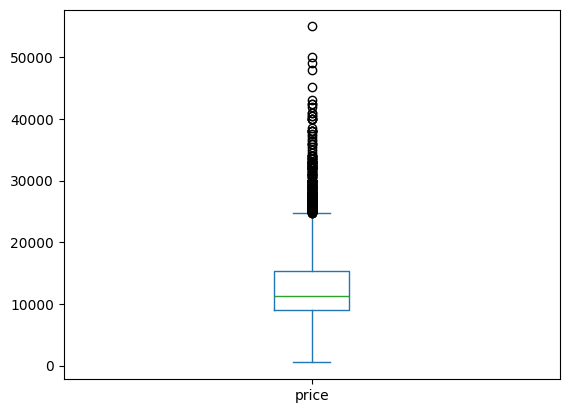

In [71]:
df['price'].plot(kind='box')

In [72]:
df['price_flag'] = df['price'] == 54995

In [73]:
df[df['price_flag']]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag
11912,Focus,2018,54995,Manual,11000,Petrol,145,36.7,2.3,True


In [74]:
df.sort_values('price').head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag
17103,Focus,2003,495,Manual,177644,Petrol,200,41.5,1.6,False
14222,Mondeo,2005,675,Manual,97000,Diesel,205,48.7,2.0,False
16904,Focus,2005,675,Manual,121000,Petrol,235,39.8,2.0,False
16811,Mondeo,2005,675,Manual,108000,Petrol,260,36.2,1.8,False
16704,Fiesta,2008,694,Manual,82020,Petrol,145,47.1,1.2,False
17248,KA,2008,795,Manual,76000,Petrol,205,43.5,1.3,False
17436,Focus,2005,795,Manual,71214,Petrol,200,42.1,1.6,False
17371,KA,2008,850,Manual,77000,Petrol,195,43.5,1.3,False
14367,Mondeo,2002,895,Manual,136784,Petrol,300,36.2,1.8,False
16907,Fiesta,2004,950,Manual,74000,Petrol,160,45.6,1.2,False


In [75]:
df[(df['model'] == 'Focus') & (df['year'] == 2003)].sort_values('price').head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag
17103,Focus,2003,495,Manual,177644,Petrol,200,41.5,1.6,False
16970,Focus,2003,1695,Manual,89630,Petrol,200,40.9,1.6,False
16819,Focus,2003,3999,Manual,56064,Petrol,325,31.0,2.0,False


In [76]:
df['mileage'].describe()

count     17811.000000
mean      23379.381955
std       19418.128363
min           1.000000
25%       10000.000000
50%       18274.000000
75%       31092.500000
max      177644.000000
Name: mileage, dtype: float64

In [77]:
df.sort_values('mileage').head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag
6930,Fiesta,2017,10995,Manual,1,Petrol,145,65.7,1.0,False
11173,Focus,2019,17880,Manual,1,Diesel,145,74.3,1.5,False
11129,EcoSport,2019,17900,Semi-Auto,1,Petrol,145,45.6,1.0,False
17193,Edge,2019,33495,Automatic,1,Diesel,145,37.2,2.0,False
16906,Mondeo,2008,1299,Manual,1,Diesel,200,47.9,2.0,False
13531,Focus,2020,19480,Automatic,2,Diesel,145,67.3,1.5,False
3654,EcoSport,2019,17550,Semi-Auto,4,Petrol,145,45.6,1.0,False
13391,Ka+,2019,10500,Manual,5,Petrol,145,47.9,1.2,False
6765,S-MAX,2019,24000,Manual,5,Petrol,145,34.0,1.5,False
3695,EcoSport,2019,17550,Semi-Auto,5,Petrol,145,45.6,1.0,False


In [78]:
df[(df['model'] == 'Mondeo') & (df['year'] == 2008)].sort_values('mileage').head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag
16906,Mondeo,2008,1299,Manual,1,Diesel,200,47.9,2.0,False
17441,Mondeo,2008,3890,Automatic,70000,Petrol,325,30.4,2.3,False
16975,Mondeo,2008,3295,Manual,85500,Petrol,300,35.8,2.0,False
16694,Mondeo,2008,1995,Manual,130000,Diesel,200,47.9,2.0,False


In [79]:
df['mileage_flag'] = ((df['model'] == 'Mondeo') & (df['year'] == 2008) & (df['mileage'] == 1))

In [80]:
df[df['mileage_flag']]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
16906,Mondeo,2008,1299,Manual,1,Diesel,200,47.9,2.0,False,True


In [81]:
df.drop(columns='mileage_flag', inplace=True)

In [82]:
df[df['mileage'] == 1][['model', 'year', 'price', 'mileage']].sort_values(['year', 'model'])

,model,year,price,mileage
16906,Mondeo,2008,1299,1
6930,Fiesta,2017,10995,1
11129,EcoSport,2019,17900,1
17193,Edge,2019,33495,1
11173,Focus,2019,17880,1


In [83]:
df.sort_values('mileage', ascending=False).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag
17103,Focus,2003,495,Manual,177644,Petrol,200,41.5,1.6,False
16946,Galaxy,2008,3995,Manual,174000,Diesel,220,44.8,1.8,False
16939,Mondeo,2012,3495,Manual,151000,Diesel,30,65.7,1.6,False
16250,Mondeo,2015,5795,Manual,150890,Diesel,30,65.7,2.0,False
17742,S-MAX,2007,2400,Manual,144000,Diesel,240,44.1,2.0,False
15709,Grand C-MAX,2011,3399,Manual,142963,Diesel,145,53.3,2.0,False
14508,Mondeo,2015,6391,Manual,142000,Diesel,20,68.9,2.0,False
16653,Focus,2008,1995,Manual,141000,Petrol,200,42.2,1.6,False
14554,Mondeo,2010,3493,Manual,140000,Diesel,145,53.3,2.0,False
16947,Focus,2009,1695,Manual,139600,Petrol,145,48.7,1.6,False


In [84]:
df['mileage_flag'] = ((df['model'] == 'Mondeo') & (df['year'] == 2008) & (df['mileage'] == 1))

In [85]:
df['tax'].describe()

count    17811.000000
mean       113.309865
std         62.032540
min          0.000000
25%         30.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64

In [86]:
df.sort_values('tax').head(100)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
30,Fiesta,2016,7999,Manual,60730,Diesel,0,78.5,1.5,False,False
27,Fiesta,2015,8299,Manual,25935,Petrol,0,65.7,1.0,False,False
24,Fiesta,2014,6795,Manual,35299,Petrol,0,65.7,1.0,False,False
14635,Fiesta,2015,7511,Manual,46243,Diesel,0,78.5,1.5,False,False
14658,Fiesta,2017,9360,Manual,25438,Petrol,0,65.7,1.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6395,Focus,2015,8810,Manual,45463,Diesel,0,74.3,1.5,False,False
6520,Fiesta,2017,6760,Manual,63998,Diesel,0,78.5,1.5,False,False
6514,Fiesta,2016,8870,Manual,20000,Diesel,0,78.5,1.5,False,False
6481,Fiesta,2015,8999,Manual,19000,Petrol,0,65.7,1.0,False,False


In [87]:
df.sort_values('tax',ascending=False).head(50)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
11097,Mustang,2016,27925,Manual,11600,Petrol,580,20.9,5.0,False,False
3163,Mustang,2017,27890,Semi-Auto,26452,Petrol,580,23.5,5.0,False,False
364,Mustang,2016,24999,Semi-Auto,42086,Petrol,570,23.5,5.0,False,False
9790,Mustang,2016,28490,Automatic,18500,Petrol,570,23.5,5.0,False,False
3687,Mustang,2016,26475,Manual,12000,Petrol,570,20.9,5.0,False,False
6136,Mustang,2016,27999,Semi-Auto,26104,Petrol,570,20.8,5.0,False,False
12400,Mustang,2017,28000,Semi-Auto,8470,Petrol,570,23.5,5.0,False,False
3395,Mustang,2017,28000,Semi-Auto,23179,Petrol,570,23.5,5.0,False,False
14910,Kuga,2012,8150,Automatic,69382,Petrol,555,27.4,2.5,False,False
17316,Kuga,2011,7499,Manual,56000,Petrol,555,28.5,2.5,False,False


In [88]:
df['mpg'].describe()

count    17811.000000
mean        57.909545
std         10.132348
min         20.800000
25%         52.300000
50%         58.900000
75%         65.700000
max        201.800000
Name: mpg, dtype: float64

In [89]:
df.sort_values('mpg',ascending=False).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
13730,Kuga,2020,32995,Automatic,11,Hybrid,135,201.8,2.5,False,False
12862,Kuga,2020,33500,Automatic,5534,Hybrid,140,201.8,2.5,False,False
6536,Kuga,2020,31991,Semi-Auto,2357,Hybrid,135,201.8,2.5,False,False
9220,Kuga,2020,32000,Automatic,10,Hybrid,140,201.8,2.5,False,False
6153,Kuga,2020,31000,Semi-Auto,10,Hybrid,135,201.8,2.5,False,False
7967,Fiesta,2017,8991,Manual,23225,Diesel,145,88.3,1.5,False,False
11730,Fiesta,2016,7490,Manual,45853,Diesel,0,88.3,1.5,False,False
1683,Fiesta,2018,8991,Manual,30500,Diesel,145,88.3,1.5,False,False
3228,Fiesta,2016,6991,Manual,54039,Diesel,0,88.3,1.5,False,False
9999,Fiesta,2017,9495,Manual,33691,Diesel,145,88.3,1.5,False,False


In [90]:
df.sort_values('mpg',ascending=True).head(20)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
13356,Mustang,2018,37500,Manual,5572,Petrol,145,20.8,5.0,False,False
7182,Mustang,2017,32990,Automatic,12000,Petrol,145,20.8,5.0,False,False
6136,Mustang,2016,27999,Semi-Auto,26104,Petrol,570,20.8,5.0,False,False
17207,Mustang,2018,30500,Manual,5000,Petrol,145,20.9,5.0,False,False
741,Mustang,2018,29998,Manual,20847,Petrol,145,20.9,5.0,False,False
13418,Mustang,2017,27500,Manual,20700,Petrol,150,20.9,5.0,False,False
11097,Mustang,2016,27925,Manual,11600,Petrol,580,20.9,5.0,False,False
3687,Mustang,2016,26475,Manual,12000,Petrol,570,20.9,5.0,False,False
10373,Mustang,2018,28615,Manual,17876,Petrol,145,20.9,5.0,False,False
11913,Mustang,2017,49999,Manual,21575,Petrol,145,20.9,5.0,False,False


In [91]:
df['engineSize'].describe()

count    17811.000000
mean         1.350620
std          0.432593
min          0.000000
25%          1.000000
50%          1.200000
75%          1.500000
max          5.000000
Name: engineSize, dtype: float64

In [92]:
df.sort_values('engineSize').head(50)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
15343,KA,2018,10000,Manual,10051,Petrol,150,43.5,0.0,False,False
15500,EcoSport,2015,8500,Manual,33403,Diesel,30,61.4,0.0,False,False
15775,Focus,2017,13000,Manual,24484,Diesel,145,70.6,0.0,False,False
16312,Focus,2015,9170,Manual,28000,Petrol,20,61.4,0.0,False,False
16313,Focus,2019,18699,Manual,10000,Petrol,145,46.3,0.0,False,False
16330,Fiesta,2017,11783,Automatic,23000,Petrol,0,57.7,0.0,False,False
16331,Fiesta,2017,9275,Automatic,34000,Petrol,0,57.7,0.0,False,False
16321,Fiesta,2017,9899,Manual,10000,Petrol,0,65.7,0.0,False,False
16322,Ka+,2018,9999,Manual,15000,Petrol,145,43.5,0.0,False,False
16323,EcoSport,2018,12973,Manual,23000,Petrol,145,54.3,0.0,False,False


In [93]:
df[(df['engineSize'] == 0)].value_counts().sum()

np.int64(51)

<Axes: xlabel='engineSize', ylabel='model'>

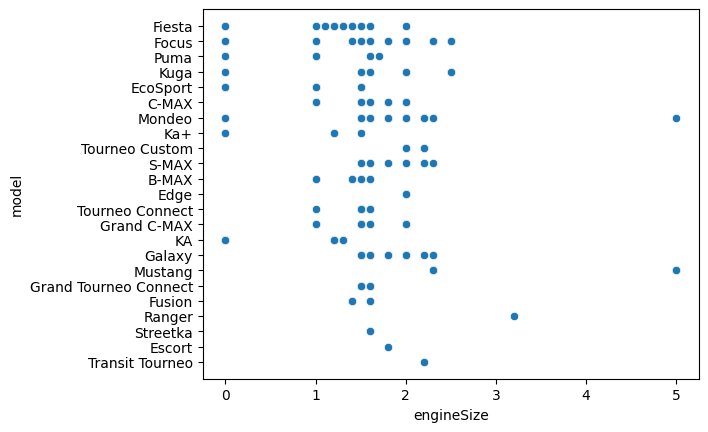

In [94]:
sns.scatterplot(data=df,x='engineSize',y='model')

In [95]:
df[df['engineSize'] == 0][['model','year','fuelType','price','engineSize']].sort_values(['model','year','fuelType'])

,model,year,fuelType,price,engineSize
15500,EcoSport,2015,Diesel,8500,0.0
16362,EcoSport,2017,Petrol,9951,0.0
16471,EcoSport,2017,Petrol,11999,0.0
16323,EcoSport,2018,Petrol,12973,0.0
16327,EcoSport,2018,Petrol,11999,0.0
16472,EcoSport,2018,Petrol,16499,0.0
16473,EcoSport,2018,Petrol,12867,0.0
16324,EcoSport,2019,Petrol,15904,0.0
16360,Fiesta,2014,Petrol,5769,0.0
16433,Fiesta,2015,Petrol,6999,0.0


In [96]:
df[(df['model'] == 'Fiesta') & (df['year'] == 2017) & (df['fuelType'] == 'Petrol')][['model','year','fuelType','price','engineSize']].sort_values('engineSize')

,model,year,fuelType,price,engineSize
16432,Fiesta,2017,Petrol,9999,0.0
16475,Fiesta,2017,Petrol,11289,0.0
16321,Fiesta,2017,Petrol,9899,0.0
16325,Fiesta,2017,Petrol,9204,0.0
16328,Fiesta,2017,Petrol,9080,0.0
...,...,...,...,...,...
12009,Fiesta,2017,Petrol,13200,1.6
10471,Fiesta,2017,Petrol,12192,1.6
10645,Fiesta,2017,Petrol,12979,1.6
10865,Fiesta,2017,Petrol,12699,1.6


In [97]:
df[df['engineSize'] != 0].groupby(['model','year','fuelType'])['engineSize'].median()

model            year  fuelType
B-MAX            2012  Diesel      1.6
                       Petrol      1.2
                 2013  Diesel      1.6
                       Petrol      1.4
                 2014  Diesel      1.6
                                  ... 
Tourneo Custom   2016  Diesel      2.0
                 2017  Diesel      2.0
                 2018  Diesel      2.0
                 2019  Diesel      2.0
Transit Tourneo  2014  Diesel      2.2
Name: engineSize, Length: 295, dtype: float64

In [98]:
df[df['engineSize'] == 0][['model', 'year', 'fuelType', 'price', 'engineSize']]

,model,year,fuelType,price,engineSize
13862,Kuga,2019,Petrol,18990,0.0
14064,Focus,2016,Diesel,15500,0.0
14082,Focus,2015,Diesel,14300,0.0
15343,KA,2018,Petrol,10000,0.0
15500,EcoSport,2015,Diesel,8500,0.0
15775,Focus,2017,Diesel,13000,0.0
16312,Focus,2015,Petrol,9170,0.0
16313,Focus,2019,Petrol,18699,0.0
16321,Fiesta,2017,Petrol,9899,0.0
16322,Ka+,2018,Petrol,9999,0.0


In [99]:
engine_medians= (df[df['engineSize'] != 0].groupby(['model','year','fuelType'])['engineSize'].median())

In [100]:
zero_rows = df[df['engineSize'] == 0]

In [101]:
matched = zero_rows.set_index(
    ['model', 'year', 'fuelType']
).index.isin(engine_medians.index)

print("Zero engine rows:", len(zero_rows))
print("Matching groups:", matched.sum())
print("Missing groups:", (~matched).sum())

Zero engine rows: 51
Matching groups: 49
Missing groups: 2


In [102]:
zero_rows[~matched][['model', 'year', 'fuelType', 'price', 'engineSize']]

,model,year,fuelType,price,engineSize
16326,Ka+,2020,Petrol,11999,0.0
16371,Puma,2019,Hybrid,23999,0.0


In [103]:
df.loc[df['engineSize'] == 0, 'engineSize'] = (
    df.loc[df['engineSize'] == 0]
      .set_index(['model', 'year', 'fuelType'])
      .index
      .map(engine_medians)
)

In [104]:
df.sort_values('engineSize')

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
5470,Fiesta,2015,7995,Manual,26638,Petrol,0,65.7,1.0,False,False
5494,Focus,2018,11000,Manual,10822,Petrol,145,60.1,1.0,False,False
5496,Fiesta,2019,15200,Manual,6868,Petrol,145,58.9,1.0,False,False
5497,EcoSport,2020,16690,Manual,151,Petrol,145,53.3,1.0,False,False
5498,Fiesta,2018,10391,Manual,12930,Petrol,145,65.7,1.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...
13431,Mustang,2019,42000,Semi-Auto,756,Petrol,150,22.6,5.0,False,False
364,Mustang,2016,24999,Semi-Auto,42086,Petrol,570,23.5,5.0,False,False
7182,Mustang,2017,32990,Automatic,12000,Petrol,145,20.8,5.0,False,False
16326,Ka+,2020,11999,Manual,2000,Petrol,145,43.5,NaN,False,False


In [105]:
df[df['model'] == "Ka+"]

df[(df['model'] == "Ka+") & (df['year'] == 2018) & (df['fuelType'] == "Petrol")]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
39,Ka+,2018,8261,Manual,25000,Petrol,145,57.7,1.2,False,False
199,Ka+,2018,8195,Manual,12231,Petrol,145,47.9,1.2,False,False
384,Ka+,2018,7999,Manual,9355,Petrol,145,57.7,1.2,False,False
416,Ka+,2018,9250,Manual,7812,Petrol,145,47.9,1.2,False,False
451,Ka+,2018,7795,Manual,9662,Petrol,145,57.7,1.2,False,False
...,...,...,...,...,...,...,...,...,...,...,...
17743,Ka+,2018,8616,Manual,13900,Petrol,145,47.9,1.2,False,False
17833,Ka+,2018,8750,Manual,9724,Petrol,150,57.7,1.2,False,False
17869,Ka+,2018,10250,Manual,4730,Petrol,145,43.5,1.2,False,False
17872,Ka+,2018,7900,Manual,16414,Petrol,145,57.7,1.2,False,False


In [106]:
df[(df['model'] == "Ka+") & (df['year'] == 2020) & (df['fuelType'] == "Petrol")]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
16326,Ka+,2020,11999,Manual,2000,Petrol,145,43.5,NaN,False,False


In [107]:
df.loc[
    (df['model'] == 'Ka+') &
    (df['year'] == 2020) &
    (df['fuelType'] == 'Petrol'),
    'engineSize'
] = 1.2

In [108]:
df[(df['model'] == 'Ka+') & (df['year'] == 2020) & (df['fuelType'] == 'Petrol')]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
16326,Ka+,2020,11999,Manual,2000,Petrol,145,43.5,1.2,False,False


In [109]:
df[
    (df['model'] == 'Ka+') &
    (df['year'] == 2020) &
    (df['fuelType'] == 'Petrol')
]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
16326,Ka+,2020,11999,Manual,2000,Petrol,145,43.5,1.2,False,False


In [110]:
df[(df['model'] == "Puma") &  (df['fuelType'] == "Hybrid")]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
16371,Puma,2019,23999,Manual,3000,Hybrid,150,50.4,NaN,False,False


In [111]:
df.sort_values(['price','year'])

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
17103,Focus,2003,495,Manual,177644,Petrol,200,41.5,1.6,False,False
14222,Mondeo,2005,675,Manual,97000,Diesel,205,48.7,2.0,False,False
16811,Mondeo,2005,675,Manual,108000,Petrol,260,36.2,1.8,False,False
16904,Focus,2005,675,Manual,121000,Petrol,235,39.8,2.0,False,False
16704,Fiesta,2008,694,Manual,82020,Petrol,145,47.1,1.2,False,False
...,...,...,...,...,...,...,...,...,...,...,...
12613,Mustang,2019,45250,Automatic,2500,Petrol,145,22.1,5.0,False,False
17866,Mustang,2020,48000,Manual,50,Petrol,145,23.9,5.0,False,False
11910,Mustang,2017,48999,Automatic,7546,Petrol,145,23.5,5.0,False,False
11913,Mustang,2017,49999,Manual,21575,Petrol,145,20.9,5.0,False,False


In [112]:
df.groupby('year')['price'].median()

year
1996     3000.0
1998     2699.0
2000     1995.0
2002     2195.0
2003     1695.0
2004     1249.5
2005     1680.0
2006     2275.0
2007     2495.0
2008     2499.0
2009     3495.0
2010     3495.0
2011     4982.5
2012     5495.0
2013     6482.5
2014     7290.0
2015     8298.0
2016     9795.0
2017    10990.0
2018    12467.5
2019    16600.0
2020    19995.0
Name: price, dtype: float64

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020')])

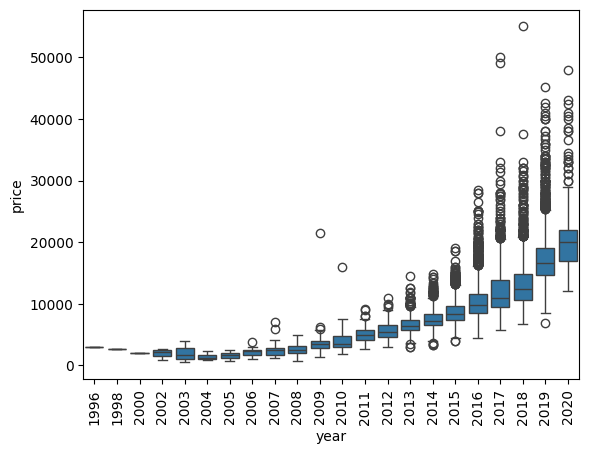

In [113]:
sns.boxplot(data=df,x= 'year',y = 'price')
plt.xticks(rotation = 90)


In [114]:
df.sort_values(['mileage','price'])

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_flag,mileage_flag
16906,Mondeo,2008,1299,Manual,1,Diesel,200,47.9,2.0,False,True
6930,Fiesta,2017,10995,Manual,1,Petrol,145,65.7,1.0,False,False
11173,Focus,2019,17880,Manual,1,Diesel,145,74.3,1.5,False,False
11129,EcoSport,2019,17900,Semi-Auto,1,Petrol,145,45.6,1.0,False,False
17193,Edge,2019,33495,Automatic,1,Diesel,145,37.2,2.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...
17742,S-MAX,2007,2400,Manual,144000,Diesel,240,44.1,2.0,False,False
16250,Mondeo,2015,5795,Manual,150890,Diesel,30,65.7,2.0,False,False
16939,Mondeo,2012,3495,Manual,151000,Diesel,30,65.7,1.6,False,False
16946,Galaxy,2008,3995,Manual,174000,Diesel,220,44.8,1.8,False,False


In [115]:
bins = [0,10000,20000,30000,50000,100000,float('inf')]

labels = [
    '0-10k',
    '10k-20k',
    '20k-30k',
    '30k-50k',
    '50k-100k',
    '100k+'
    
]

df['mileage_group'] = pd.cut(
    df['mileage'],
    bins=bins,
    labels=labels
)

In [116]:
df.groupby('mileage_group', observed=True)['price'].median()

mileage_group
0-10k       15399.5
10k-20k     11980.0
20k-30k     10498.0
30k-50k      9456.5
50k-100k     6995.0
100k+        3944.5
Name: price, dtype: float64

<Axes: xlabel='mileage', ylabel='price'>

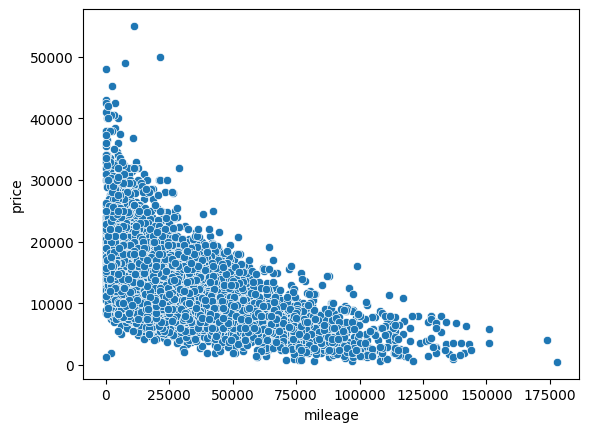

In [117]:
sns.scatterplot(data=df, x='mileage',y='price')

In [118]:
df.groupby('tax')['price'].median()

tax
0       8700.0
20      9499.5
22      8299.0
30      7498.0
110    10700.0
115    10995.0
120     5445.0
125     9698.0
135    25645.0
140    22749.0
145    13695.0
150    12495.0
155     6499.0
160     9895.0
165     9000.0
185     1295.0
190     4000.0
195     4745.0
200    10000.0
205     9990.0
210     3875.0
220     3995.0
230     7345.0
235    14942.5
240    14374.5
260    10698.0
265     5295.0
270     1999.0
290     1850.0
300     3395.0
305     2897.5
325     7242.5
330    13747.5
555     7824.5
570    27999.5
580    27907.5
Name: price, dtype: float64

<Axes: xlabel='tax', ylabel='price'>

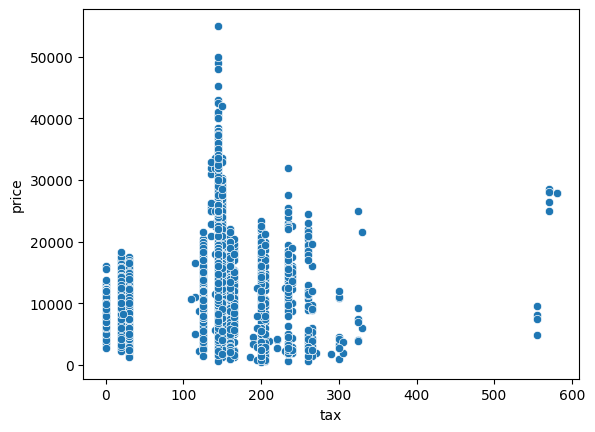

In [119]:
sns.scatterplot(data=df,x='tax',y='price')

In [120]:
df.groupby('mpg')['price'].median()

mpg
20.8     32990.0
20.9     28489.0
22.1     39990.0
22.6     40999.0
22.8     40500.0
          ...   
80.7     15000.0
83.1      8148.5
85.6      7100.0
88.3      9299.0
201.8    32000.0
Name: price, Length: 90, dtype: float64

<Axes: xlabel='mpg', ylabel='price'>

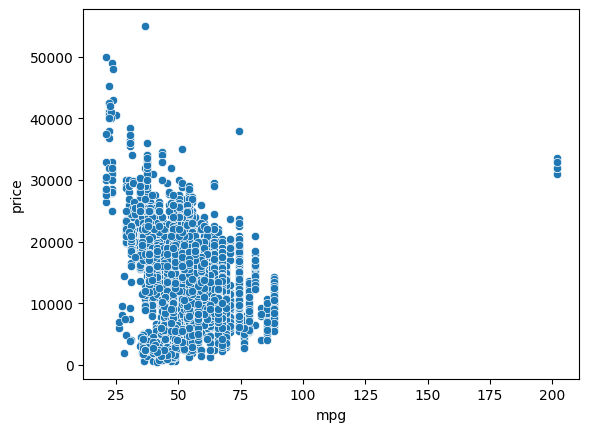

In [121]:
sns.scatterplot(data=df, x= 'mpg',y='price')

In [122]:
df.groupby('engineSize')['price'].median()

engineSize
1.0    11250.0
1.1     9993.0
1.2     7599.0
1.3     1672.5
1.4     5176.0
1.5    11999.0
1.6     7600.0
1.7     2195.0
1.8     2995.0
2.0    16500.0
2.2    11000.0
2.3    26274.5
2.5     9490.0
3.2    14495.0
5.0    33000.0
Name: price, dtype: float64

<Axes: xlabel='engineSize', ylabel='price'>

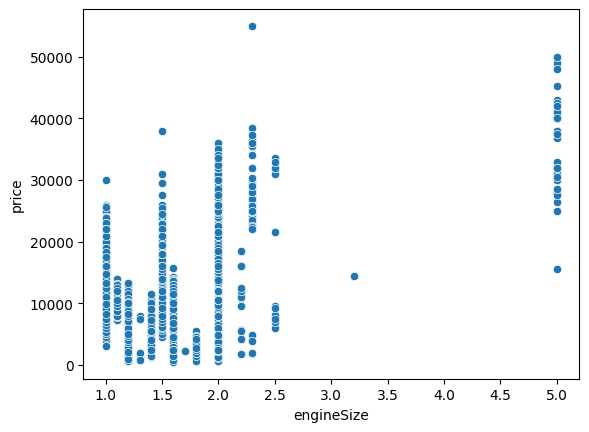

In [123]:
sns.scatterplot(data=df,x='engineSize',y= 'price')

In [124]:
df.groupby('model')['price'].median().sort_values(ascending=False)

model
Mustang                  33979.0
Puma                     21495.0
Edge                     20800.0
Tourneo Custom           20000.0
Galaxy                   18000.0
S-MAX                    17247.0
Kuga                     15972.5
Ranger                   14495.0
Grand Tourneo Connect    14000.0
Tourneo Connect          12999.0
Focus                    12725.0
Transit Tourneo          12450.0
EcoSport                 12000.0
Mondeo                   11544.5
Grand C-MAX              10798.0
C-MAX                    10000.0
Fiesta                    9995.0
Ka+                       8295.0
B-MAX                     8250.0
KA                        4800.0
Escort                    3000.0
Fusion                    2443.0
Streetka                  1924.5
Name: price, dtype: float64

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'Fiesta'),
  Text(1, 0, 'Focus'),
  Text(2, 0, 'Puma'),
  Text(3, 0, 'Kuga'),
  Text(4, 0, 'EcoSport'),
  Text(5, 0, 'C-MAX'),
  Text(6, 0, 'Mondeo'),
  Text(7, 0, 'Ka+'),
  Text(8, 0, 'Tourneo Custom'),
  Text(9, 0, 'S-MAX'),
  Text(10, 0, 'B-MAX'),
  Text(11, 0, 'Edge'),
  Text(12, 0, 'Tourneo Connect'),
  Text(13, 0, 'Grand C-MAX'),
  Text(14, 0, 'KA'),
  Text(15, 0, 'Galaxy'),
  Text(16, 0, 'Mustang'),
  Text(17, 0, 'Grand Tourneo Connect'),
  Text(18, 0, 'Fusion'),
  Text(19, 0, 'Ranger'),
  Text(20, 0, 'Streetka'),
  Text(21, 0, 'Escort'),
  Text(22, 0, 'Transit Tourneo')])

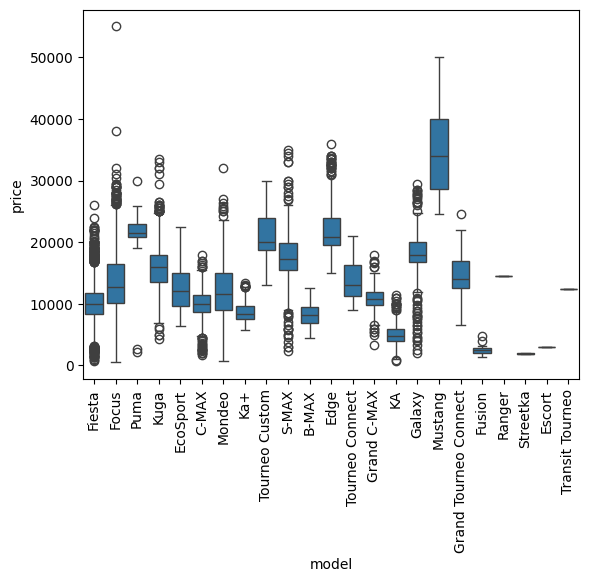

In [125]:
sns.boxplot(data=df,x='model',y='price')
plt.xticks(rotation = 90)

In [126]:
df.groupby('transmission')['price'].median()

transmission
Automatic    15695.0
Manual       10990.0
Semi-Auto    13660.0
Name: price, dtype: float64

In [127]:
df.groupby('fuelType')['price'].median()

fuelType
Diesel      13260.0
Electric    15737.5
Hybrid      23498.5
Other       13800.0
Petrol      10799.0
Name: price, dtype: float64

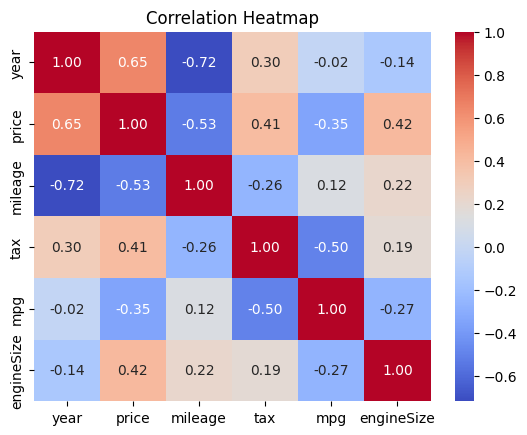

In [128]:
sns.heatmap(df[['year','price','mileage','tax','mpg','engineSize']].corr(),annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

<Axes: xlabel='year', ylabel='mileage'>

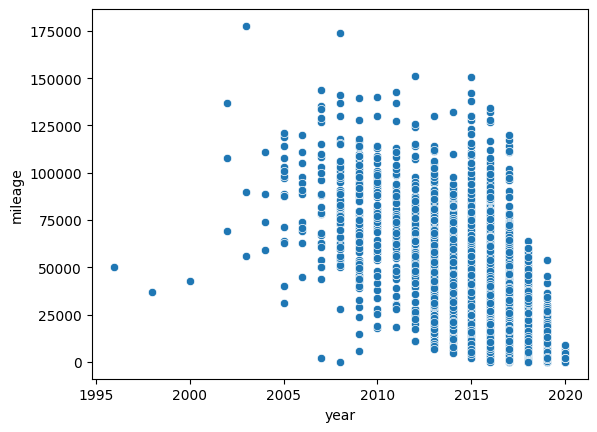

In [129]:
sns.scatterplot(data=df,x='year',y='mileage')

In [131]:
df['car_age'] = 2020 - df['year']

In [132]:
df[['year', 'car_age']].head(10)

,year,car_age
0,2017,3
1,2018,2
2,2017,3
3,2019,1
4,2019,1
5,2015,5
6,2019,1
7,2017,3
8,2019,1
9,2018,2


In [133]:
df[['year', 'car_age']].corr()

,year,car_age
year,1.0,-1.0
car_age,-1.0,1.0


In [134]:
df[['car_age', 'mileage', 'tax', 'mpg', 'engineSize', 'price']].corr()

,car_age,mileage,tax,mpg,engineSize,price
car_age,1.000000,0.719636,-0.299192,0.020195,0.139960,-0.645236
mileage,0.719636,1.000000,-0.257712,0.117849,0.216750,-0.530433
tax,-0.299192,-0.257712,1.000000,-0.502282,0.187120,0.406112
mpg,0.020195,0.117849,-0.502282,1.000000,-0.266528,-0.346401
engineSize,0.139960,0.216750,0.187120,-0.266528,1.000000,0.416281
price,-0.645236,-0.530433,0.406112,-0.346401,0.416281,1.000000


In [139]:
df.columns

Index(['model', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize', 'price_flag', 'mileage_flag', 'mileage_group', 'car_age'],
      dtype='object')

In [140]:
df[['model','transmission','fuelType']].nunique()

model           23
transmission     3
fuelType         5
dtype: int64

In [141]:
df[['model', 'transmission', 'fuelType']].apply(lambda x: x.unique())

model           [Fiesta, Focus, Puma, Kuga, EcoSport, C-MAX, M...
transmission                       [Automatic, Manual, Semi-Auto]
fuelType                [Petrol, Diesel, Hybrid, Electric, Other]
dtype: object

In [142]:
df.drop(columns=['price_flag','mileage_flag','mileage_group'],inplace=True)

In [143]:
df.columns

Index(['model', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize', 'car_age'],
      dtype='object')

#Encoding

In [144]:
X= df.drop(columns='price')
y= df['price']

In [145]:
X,y

(        model transmission  mileage fuelType  tax   mpg  engineSize  car_age
 0      Fiesta    Automatic    15944   Petrol  150  57.7         1.0        3
 1       Focus       Manual     9083   Petrol  150  57.7         1.0        2
 2       Focus       Manual    12456   Petrol  150  57.7         1.0        3
 3      Fiesta       Manual    10460   Petrol  145  40.3         1.5        1
 4      Fiesta    Automatic     1482   Petrol  145  48.7         1.0        1
 ...       ...          ...      ...      ...  ...   ...         ...      ...
 17961   B-MAX       Manual    16700   Petrol  150  47.1         1.4        3
 17962   B-MAX       Manual    40700   Petrol   30  57.7         1.0        6
 17963   Focus       Manual     7010   Diesel   20  67.3         1.6        5
 17964      KA       Manual     5007   Petrol  145  57.7         1.2        2
 17965   Focus       Manual     5007   Petrol   22  57.7         1.0        5
 
 [17811 rows x 8 columns],
 0        12000
 1        14000
 2 

In [146]:
X.select_dtypes(include='object').columns

Index(['model', 'transmission', 'fuelType'], dtype='object')

In [147]:
X_encoded = pd.get_dummies(X,columns=['model','transmission','fuelType'],drop_first=True)

In [150]:
X_encoded = X_encoded.astype({
    col: int for col in X_encoded.select_dtypes(include='bool').columns
})

In [151]:
X_encoded

,mileage,tax,mpg,engineSize,car_age,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,...,model_Streetka,model_Tourneo Connect,model_Tourneo Custom,model_Transit Tourneo,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,15944,150,57.7,1.0,3,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,9083,150,57.7,1.0,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,12456,150,57.7,1.0,3,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,10460,145,40.3,1.5,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1482,145,48.7,1.0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,16700,150,47.1,1.4,3,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,40700,30,57.7,1.0,6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,7010,20,67.3,1.6,5,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,5007,145,57.7,1.2,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [152]:
X_encoded.dtypes

mileage                          int64
tax                              int64
mpg                            float64
engineSize                     float64
car_age                          int64
model_C-MAX                      int64
model_EcoSport                   int64
model_Edge                       int64
model_Escort                     int64
model_Fiesta                     int64
model_Focus                      int64
model_Fusion                     int64
model_Galaxy                     int64
model_Grand C-MAX                int64
model_Grand Tourneo Connect      int64
model_KA                         int64
model_Ka+                        int64
model_Kuga                       int64
model_Mondeo                     int64
model_Mustang                    int64
model_Puma                       int64
model_Ranger                     int64
model_S-MAX                      int64
model_Streetka                   int64
model_Tourneo Connect            int64
model_Tourneo Custom     

In [153]:
X_encoded.shape

(17811, 33)

In [154]:
X_encoded.isnull().sum().sum()

np.int64(1)

In [155]:
X_encoded[X_encoded.isnull().any(axis=1)]

,mileage,tax,mpg,engineSize,car_age,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,...,model_Streetka,model_Tourneo Connect,model_Tourneo Custom,model_Transit Tourneo,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
16371,3000,150,50.4,NaN,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


In [157]:
missing_index = X_encoded[X_encoded.isnull().any(axis=1)].index
missing_index

Index([16371], dtype='int64')

In [158]:
X_encoded = X_encoded.drop(index=missing_index)
y = y.drop(index=missing_index)

In [162]:
from sklearn.model_selection import train_test_split

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

In [174]:
from sklearn.preprocessing import StandardScaler


numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'car_age']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)


In [175]:
X_encoded.head()

,mileage,tax,mpg,engineSize,car_age,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,...,model_Streetka,model_Tourneo Connect,model_Tourneo Custom,model_Transit Tourneo,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,15944,150,57.7,1.0,3,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,9083,150,57.7,1.0,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,12456,150,57.7,1.0,3,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,10460,145,40.3,1.5,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1482,145,48.7,1.0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [176]:
X_train_scaled.head()

,mileage,tax,mpg,engineSize,car_age,model_C-MAX,model_EcoSport,model_Edge,model_Escort,model_Fiesta,...,model_Streetka,model_Tourneo Connect,model_Tourneo Custom,model_Transit Tourneo,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
12869,0.279034,0.194376,-0.644251,-0.835674,-0.072367,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
11051,0.445678,-1.502923,0.342898,-0.835674,0.912438,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
16748,2.699921,-1.826218,0.767371,-0.835674,1.897243,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
7819,0.085115,-1.341275,-0.249391,-0.835674,0.420035,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
6618,0.846172,-1.826218,1.616319,0.350912,0.420035,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [177]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train_scaled,y_train)

LinearRegression()

In [178]:
model.coef_

array([-1194.42847111,   -87.68737006,  -711.90217779,  1324.46860453,
       -2306.9623904 ,  1185.2858535 ,  1659.80547528,  9164.10431628,
       15469.486631  ,  1094.06247611,  3141.40982993,  3677.84998947,
        6651.8965835 ,  1662.31594298,  4216.01660448,  -661.25158965,
       -3031.2431794 ,  3677.49946592,  2695.17017953, 11069.78130029,
        8100.74557449,  5264.85230794,  6174.725695  ,  5476.28611525,
        3568.54696739,  6943.09234984,  1970.12325153,  -483.28802718,
        -141.70453248,  1710.45001426,  6501.44286773,  1063.55571882,
         131.56764974])

In [180]:
y_pred=model.predict(X_test_scaled)
y_pred

array([11964.92165692,  5229.30463335, 11130.00495872, ...,
       13216.58209641, 14301.73434905,  8764.97722639])

In [183]:
from sklearn.metrics import r2_score

r2=r2_score(y_pred,y_test)
r2

0.8367225149470472

In [184]:
n= X_test.shape[0]
p=X_test.shape[1]

adjusted_r2= 1- ((1 - r2) * (n - 1) / (n-p-1))
adjusted_r2

0.8351952595596471

╔══════════════════════════════════════════════════════════════════════╗
║              🚗 FORD CAR PRICE PREDICTION — OUR WORKFLOW            ║
║                    Exact steps WE performed                         ║
╚══════════════════════════════════════════════════════════════════════╝


1. LOAD THE FORD DATASET
│
├── Dataset → Ford car listings
│
├── Initial shape
│   └── 17,966 rows × 9 columns
│
└── Columns
    ├── model
    ├── year
    ├── price              ← 🎯 TARGET
    ├── transmission
    ├── mileage
    ├── fuelType
    ├── tax
    ├── mpg
    └── engineSize
        ↓


2. INITIAL DATA UNDERSTANDING
│
├── df.head()
│   └── Viewed first records
│
├── df.shape
│   └── Understood dataset size
│
├── df.info()
│   └── Checked data types / null information
│
├── df.describe()
│   └── Checked numerical statistics
│
└── Identified:
    ├── Numerical columns
    │   ├── year
    │   ├── price
    │   ├── mileage
    │   ├── tax
    │   ├── mpg
    │   └── engineSize
    │
    └── Categorical columns
        ├── model
        ├── transmission
        └── fuelType
        ↓


3. CHECK DUPLICATES
│
├── Checked:
│   └── df.duplicated().sum()
│
├── Found:
│   └── 154 duplicates
│
├── Inspected duplicate records
│
├── Confirmed they were exact duplicates
│
└── Removed:
    └── df = df.drop_duplicates()
│
└── Remaining:
    └── 17,812 rows
        ↓


4. CLEAN TEXT / CATEGORIES
│
├── Inspected model values
│
├── Found leading spaces
│   ├── " Fiesta"
│   ├── " Focus"
│   └── etc.
│
└── Cleaned:
    └── df['model'] = df['model'].str.strip()
        ↓


5. INVESTIGATE YEAR
│
├── df['year'].describe()
│
├── Found:
│   └── maximum year = 2060
│
├── Investigated records > 2025
│
├── Found one:
│   └── Fiesta, year = 2060
│
├── Checked year distribution
│
├── Found:
│   └── 2020 was the latest legitimate year
│
├── Conclusion:
│   └── 2060 = invalid data-entry value
│
└── Removed:
    └── df = df[df['year'] <= 2020]
│
└── Final max year = 2020
        ↓


6. INVESTIGATE PRICE
│
├── Checked df['price'].describe()
│
├── Investigated highest prices
│
├── Found suspicious:
│   └── Focus → £54,995
│
├── Compared with other Focus / 2.3L Focus cars
│
├── Found it was unusually high
│
├── BUT:
│   └── Could not prove it was invalid
│
├── Therefore:
│   └── DID NOT DELETE IT
│
└── Temporarily created:
    └── price_flag
        ↓
    Later removed temporary flag
        ↓


7. INVESTIGATE MILEAGE
│
├── Checked mileage statistics
│
├── Investigated highest mileage
│   ├── 177,644
│   ├── 136,784
│   ├── 130,000
│   └── etc.
│
├── Found them plausible for older cars
│
├── Investigated lowest mileage
│
├── Found many cars with:
│   └── mileage = 1
│
├── Did NOT delete all 1-mile cars
│   └── Some newer/demo cars can legitimately have very
│       low mileage
│
├── Found one suspicious combination:
│   ├── Model → Mondeo
│   ├── Year → 2008
│   ├── Mileage → 1
│   └── Price → £1,299
│
├── Compared with other 2008 Mondeos
│
└── Flagged this specific record
    └── mileage_flag
        ↓


8. INVESTIGATE TAX
│
├── Checked tax statistics
│
├── Initially questioned:
│   └── tax = 0
│
├── Investigated examples
│
├── Found many legitimate £0-tax cars
│
├── Investigated high tax
│   ├── £570
│   ├── £580
│   └── etc.
│
├── Found large-engine petrol cars
│   └── Mustangs, etc.
│
└── Conclusion:
    ├── tax = 0 → legitimate
    └── tax = 580 → legitimate
        ↓
    No tax cleaning required
        ↓


9. INVESTIGATE MPG
│
├── Checked mpg statistics
│
├── Found very high:
│   └── 201.8 MPG
│
├── Investigated those records
│
├── Found newer hybrid vehicles
│
├── Investigated low MPG
│   └── ~20–22 MPG
│
├── Found large-engine Mustangs
│
└── Conclusion:
    ├── High MPG → legitimate
    └── Low MPG → legitimate
        ↓
    No MPG cleaning required
        ↓


10. INVESTIGATE ENGINE SIZE
│
├── Checked engineSize statistics
│
├── Found:
│   └── engineSize = 0
│
├── Number of zero values:
│   └── 51
│
├── Investigated those records
│
├── Found zeros across different models
│
└── Conclusion:
    └── 0 was being used as a missing/unknown placeholder
        ↓


11. HANDLE engineSize = 0
│
├── Created median lookup based on:
│   ├── model
│   ├── year
│   └── fuelType
│
├── Used only:
│   └── engineSize != 0
│
├── Calculated group medians
│
├── Checked zero rows
│
├── 51 zero rows
│   ├── 49 → matching groups
│   └── 2 → no matching groups
│
├── Filled 49 values using group median
│
├── Remaining:
│
│   ├── Ka+ | 2020 | Petrol
│   │
│   ├── Investigated older Ka+ records
│   ├── Found 1.2L pattern
│   └── Filled → 1.2
│   │
│   └── Puma | 2019 | Hybrid
│       ├── Only one such record
│       ├── No reliable comparable group
│       └── Left as NaN
│
└── Final decision:
    └── Don't invent information when evidence is insufficient
        ↓


12. EDA — PRICE VS YEAR
│
├── Grouped price by year
│
├── Calculated median prices
│
├── Observed:
│   ├── Older cars → generally cheaper
│   └── Newer cars → generally more expensive
│
├── Created boxplot
│
└── Conclusion:
    └── year is an important price-related feature
        ↓


13. EDA — PRICE VS MILEAGE
│
├── Created mileage groups:
│   ├── 0–10k
│   ├── 10k–20k
│   ├── 20k–30k
│   ├── 30k–50k
│   ├── 50k–100k
│   └── 100k+
│
├── Compared median price
│
├── Observed:
│   └── Higher mileage → generally lower price
│
├── Created scatter plot
│
└── Conclusion:
    └── mileage is an important feature
        ↓


14. EDA — PRICE VS TAX
│
├── Grouped price by tax
│
├── Created scatter plot
│
├── Observed:
│   └── No simple smooth relationship
│
└── Conclusion:
    └── Keep tax because it may still contain useful information
        ↓


15. EDA — PRICE VS MPG
│
├── Grouped price by MPG
│
├── Created scatter plot
│
├── Observed:
│   └── Complex / weak overall relationship
│
├── Hybrid cars explained very high MPG values
│
└── Conclusion:
    └── Keep mpg
        ↓


16. EDA — PRICE VS ENGINE SIZE
│
├── Grouped price by engineSize
│
├── Created scatter plot
│
├── Observed:
│   └── Larger engines can be associated with higher prices
│       but relationship is not simple
│
└── Conclusion:
    └── Keep engineSize
        ↓


17. EDA — CATEGORICAL FEATURES
│
├── PRICE vs MODEL
│   ├── Grouped median price
│   ├── Created boxplot
│   └── Found large differences between models
│
├── PRICE vs TRANSMISSION
│   ├── Grouped median price
│   └── Automatic / Semi-Auto / Manual showed differences
│
└── PRICE vs FUEL TYPE
    ├── Grouped median price
    └── Different fuel types showed different price levels
        ↓


18. CORRELATION ANALYSIS
│
├── Created correlation matrix
│
├── Created heatmap
│
├── Important relationships:
│   ├── year ↔ price       → +0.65
│   ├── mileage ↔ price    → -0.53
│   ├── engineSize ↔ price → +0.42
│   ├── tax ↔ price        → +0.41
│   ├── mpg ↔ price        → -0.35
│   └── year ↔ mileage     → -0.72
│
├── Learned:
│   ├── Positive correlation
│   ├── Negative correlation
│   ├── Strength of relationship
│   └── Correlation ≠ causation
│
└── Used this information to help
    understand feature relationships
        ↓


19. FEATURE ENGINEERING
│
├── Created:
│   └── car_age
│
├── Formula:
│   └── car_age = 2020 - year
│
├── Example:
│   ├── 2017 → 3 years
│   ├── 2018 → 2 years
│   └── 2019 → 1 year
│
└── Reason:
    └── More directly represents vehicle age
        ↓


20. FEATURE SELECTION
│
├── Compared:
│   ├── year
│   └── car_age
│
├── Realized:
│   └── car_age = 2020 - year
│
├── Therefore they contain the same information
│
├── For Linear Regression:
│   └── Keeping both creates perfect linear dependence
│
└── Decision:
    ├── Keep car_age
    └── Remove year
        ↓


21. FINAL FEATURE SET
│
├── Numerical:
│   ├── mileage
│   ├── tax
│   ├── mpg
│   ├── engineSize
│   └── car_age
│
├── Categorical:
│   ├── model
│   ├── transmission
│   └── fuelType
│
└── Target:
    └── price
        ↓


22. REMOVE TEMPORARY EDA / INVESTIGATION COLUMNS
│
└── Removed:
    ├── price_flag
    ├── mileage_flag
    └── mileage_group
        ↓


23. CREATE X AND y
│
├── X:
│   └── df.drop(columns='price')
│
└── y:
    └── df['price']
        ↓


24. ONE-HOT ENCODING
│
├── Encoded:
│   ├── model
│   ├── transmission
│   └── fuelType
│
├── Used:
│   └── pd.get_dummies()
│
├── Used:
│   └── drop_first=True
│
├── Numerical columns remained numerical
│
└── Result:
    └── X_encoded
        ↓
    33 model features
        ↓


25. FINAL MISSING-VALUE CHECK
│
├── Checked:
│   └── X_encoded.isnull().sum().sum()
│
├── Found:
│   └── 1 missing value
│
├── Located:
│   └── Puma 2019 Hybrid
│
├── Since engine size couldn't be
│   reliably determined:
│
└── Removed same index from:
    ├── X_encoded
    └── y
        ↓
    X and y remain aligned
        ↓


26. TRAIN / TEST SPLIT
│
├── Used:
│   └── train_test_split()
│
├── test_size = 0.20
│
├── random_state = 42
│
└── Created:
    ├── X_train
    ├── X_test
    ├── y_train
    └── y_test
        ↓


27. STANDARD SCALING
│
├── Selected numerical columns:
│   ├── mileage
│   ├── tax
│   ├── mpg
│   ├── engineSize
│   └── car_age
│
├── Created:
│   └── scaler = StandardScaler()
│
├── Made copies:
│   ├── X_train_scaled = X_train.copy()
│   └── X_test_scaled = X_test.copy()
│
├── TRAIN:
│   └── scaler.fit_transform()
│       ├── fit → learns mean + std from X_train
│       └── transform → scales X_train
│
├── TEST:
│   └── scaler.transform()
│       └── uses training mean + std
│
└── Reason:
    └── Avoid data leakage
        ↓


28. CREATE LINEAR REGRESSION MODEL
│
├── Imported:
│   └── LinearRegression
│
└── Created:
    └── model = LinearRegression()
        ↓


29. TRAIN THE MODEL
│
└── Used:
    └── model.fit(X_train_scaled, y_train)
        │
        └── Model learns relationship:
            features → price
        ↓


30. MAKE PREDICTIONS
│
└── Used:
    └── y_pred = model.predict(X_test_scaled)
        │
        └── Predicted prices for unseen test cars
        ↓


31. CALCULATE R²
│
├── Used:
│   └── r2_score(y_test, y_pred)
│
└── OUR RESULT:
    └── R² = 0.83672
        ↓


32. CALCULATE ADJUSTED R²
│
├── n = number of test observations
│
├── p = number of features
│
└── Formula:
    └── 1 - (1-r²)(n-1)/(n-p-1)
        ↓
    OUR RESULT:
    └── Adjusted R² = 0.83520
        ↓


33. FINAL COMPARISON
│
├── MENTOR MODEL
│   ├── R² ≈ 0.8240
│   └── Adjusted R² ≈ 0.82235
│
├── OUR IMPROVED MODEL
│   ├── R² = 0.83672
│   └── Adjusted R² = 0.83520
│
└── RESULT:
    ├── R² improvement ≈ +0.0127
    └── Adjusted R² improvement ≈ +0.0129
        ↓


╔══════════════════════════════════════════════════════════════════════╗
║                    🚗 FORD PROJECT COMPLETE ✅                      ║
╚══════════════════════════════════════════════════════════════════════╝